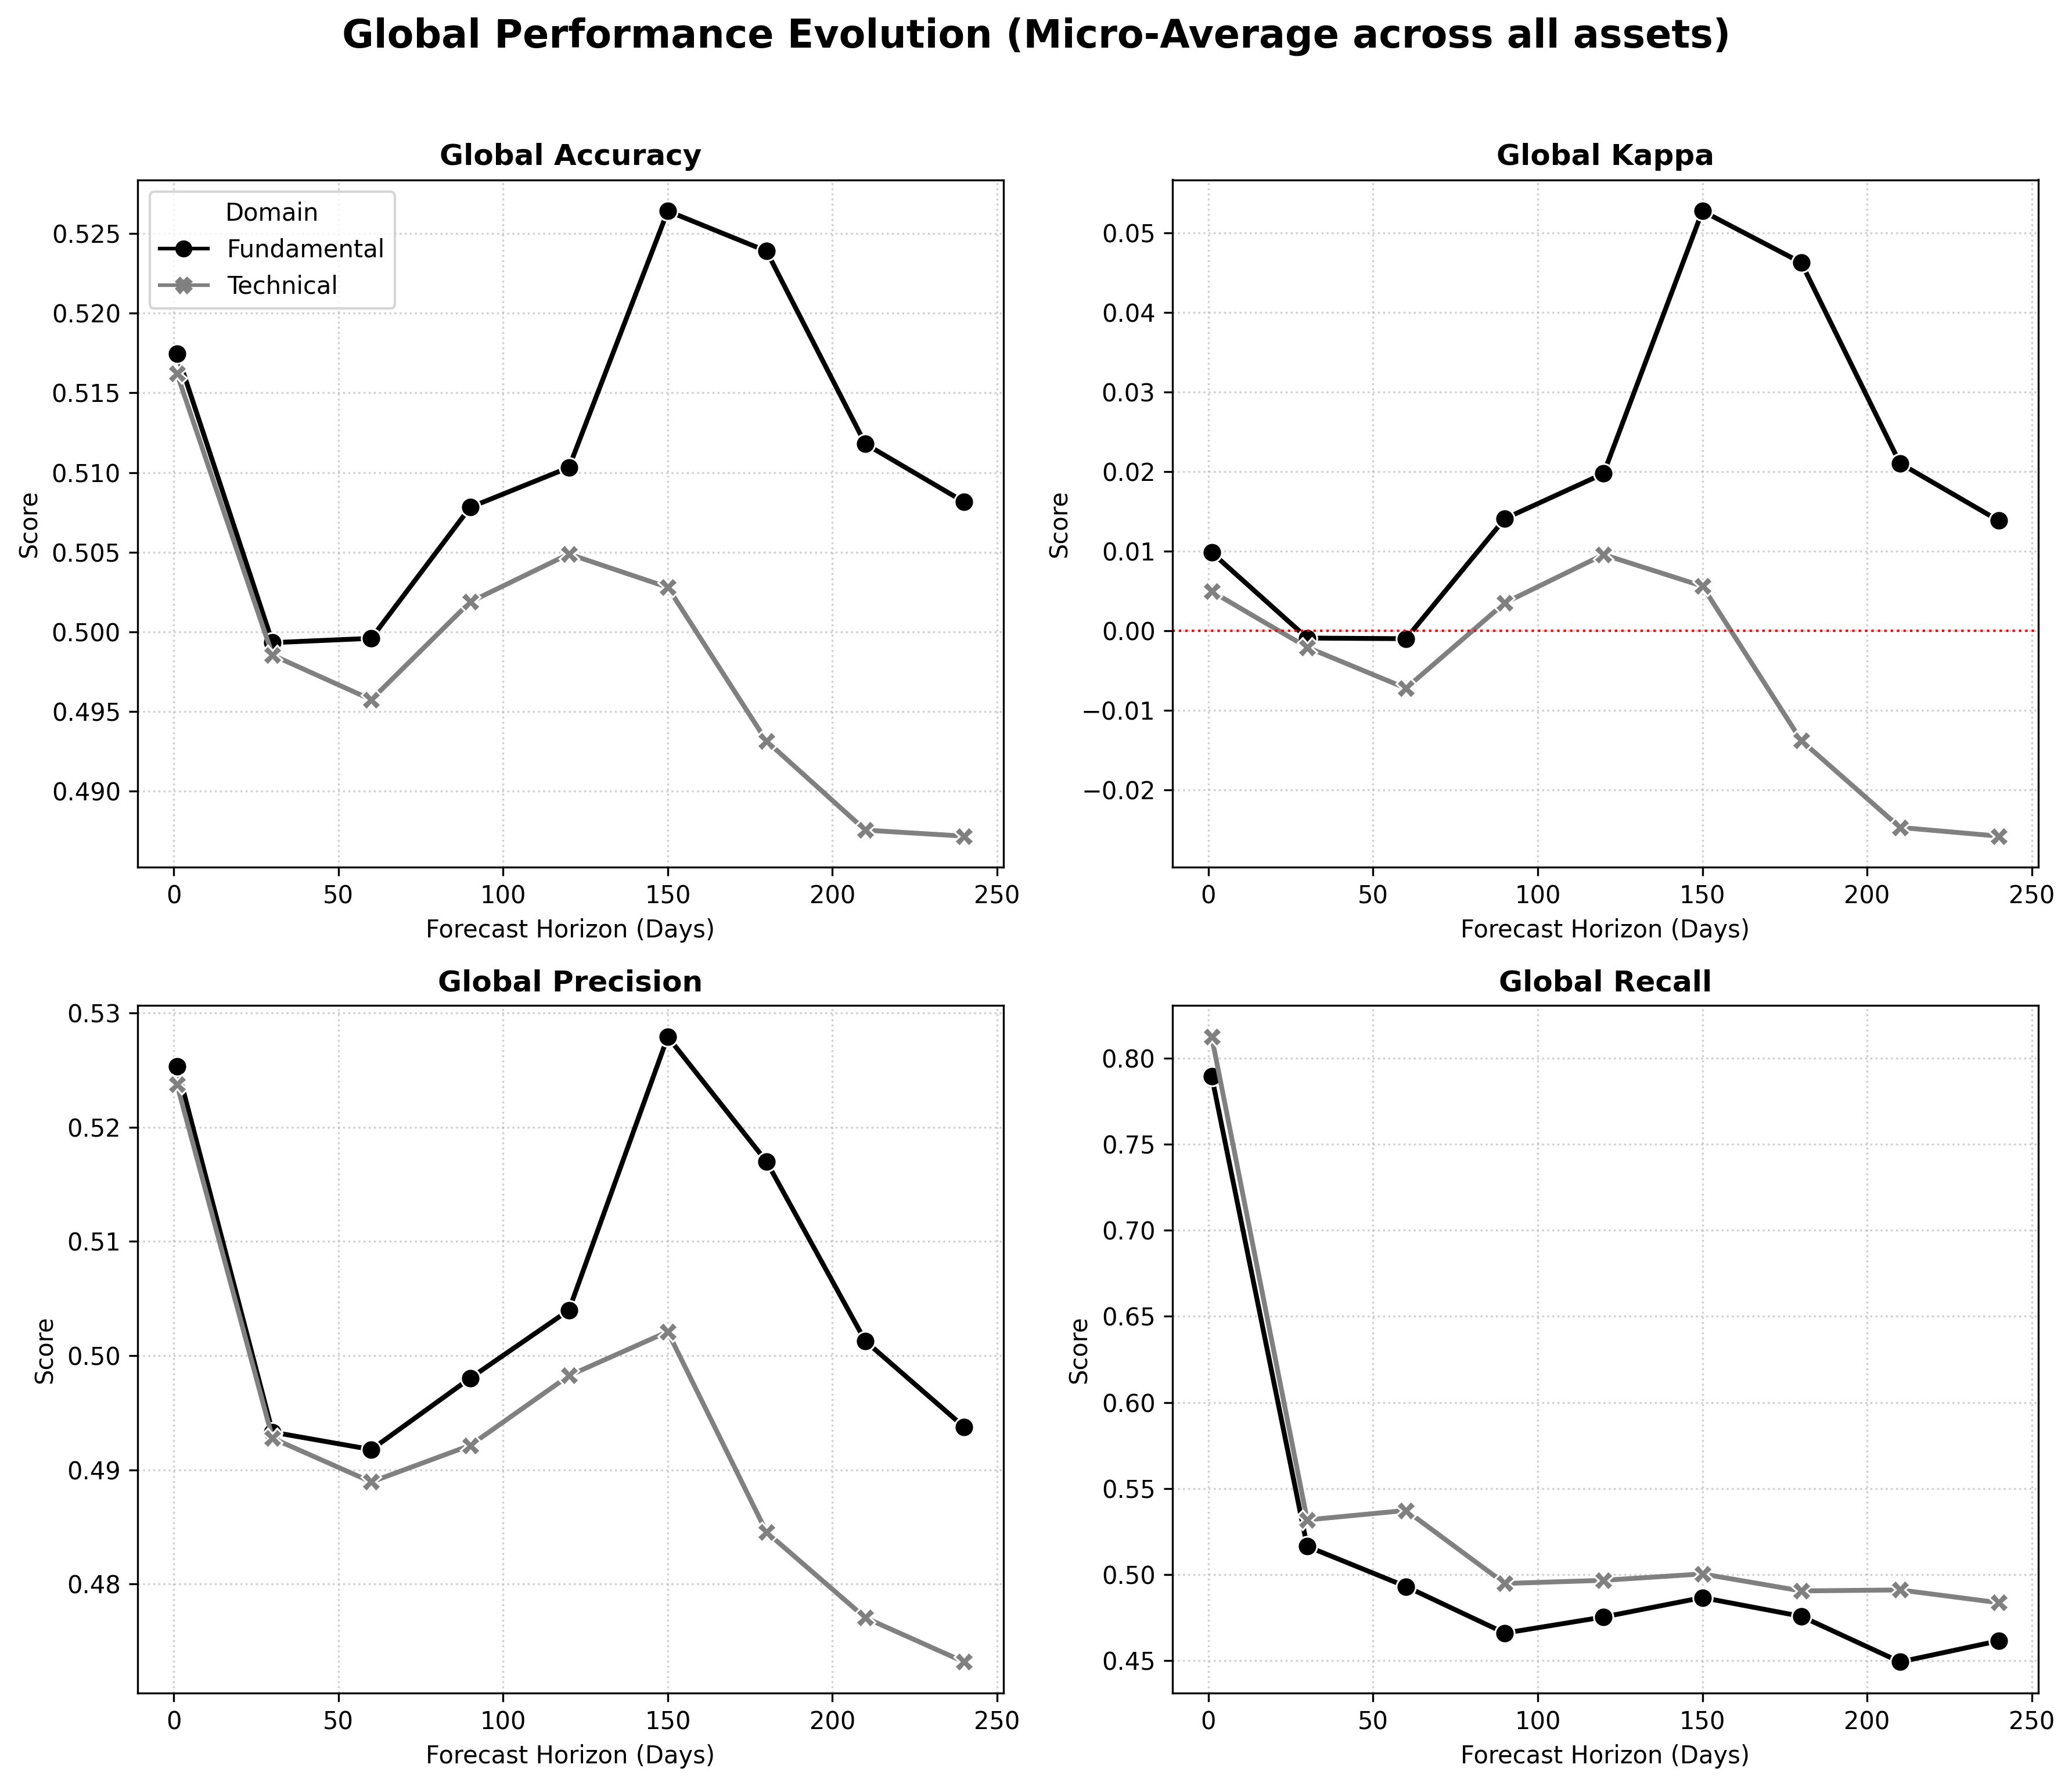

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

# ==============================================================================
# 1. CONFIGURAÇÕES
# ==============================================================================
modelo = 'HT'
atraso_selecionado = 1
caminho_base = 'resultados'
nome_arquivo_saida = 'global_metrics_by_horizon.pdf'

mapa_nomes = {'fund': 'Fundamental', 'nao_fund': 'Technical'}
cores = {'Fundamental': 'black', 'Technical': 'gray'}

# --- CORREÇÃO AQUI ---
# Definimos explicitamente quais símbolos usar. 
# 'o' = bolinha, 'X' = xis (X maiúsculo fica mais visível que x minúsculo)
marcadores = {'Fundamental': 'o', 'Technical': 'X'} 
# ---------------------

# ==============================================================================
# 2. CARREGAMENTO E PREPARAÇÃO
# ==============================================================================
nome_arquivo = f'resultados_{modelo}_atraso_{atraso_selecionado}.csv'
caminho_completo = os.path.join(caminho_base, nome_arquivo)

# Mock de dados (MANTIDO IGUAL AO SEU)
if not os.path.exists(caminho_completo):
    print("AVISO: Criando dados simulados (MOCK).")
    data = []
    horizontes = [1, 5, 10, 20, 60, 120, 150, 180, 240]
    for cat in ['fund', 'nao_fund']:
        for h in horizontes:
            for asset in range(58):
                if cat == 'fund':
                    acc_base = 0.50 + (0.05 if h > 100 else 0)
                else:
                    acc_base = 0.50 - (0.0005 * h)
                
                n_samples = 100
                tp = int(n_samples * acc_base * 0.5)
                tn = int(n_samples * acc_base * 0.5)
                fp = int(n_samples * (1-acc_base) * 0.5)
                fn = n_samples - tp - tn - fp
                
                data.append({
                    'categoria': cat,
                    'fh': h, # Atenção: no seu código original estava 'horizon' no mock e 'fh' no plot, ajustei para 'fh'
                    'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn
                })
    df = pd.DataFrame(data)
else:
    df = pd.read_csv(caminho_completo)

# ==============================================================================
# 3. CÁLCULO DAS MÉTRICAS GLOBAIS
# ==============================================================================
# (Lógica mantida igual)
df_global = df.groupby(['categoria', 'fh'])[['TP', 'TN', 'FP', 'FN']].sum().reset_index()

total = df_global['TP'] + df_global['TN'] + df_global['FP'] + df_global['FN']
df_global['Global_Accuracy'] = (df_global['TP'] + df_global['TN']) / total

Po = df_global['Global_Accuracy']
Pe_pos = ((df_global['TP'] + df_global['FP']) * (df_global['TP'] + df_global['FN'])) / (total**2)
Pe_neg = ((df_global['TN'] + df_global['FN']) * (df_global['TN'] + df_global['FP'])) / (total**2)
Pe = Pe_pos + Pe_neg
df_global['Global_Kappa'] = (Po - Pe) / (1 - Pe)

df_global['Global_Precision'] = df_global['TP'] / (df_global['TP'] + df_global['FP'])
df_global['Global_Recall'] = df_global['TP'] / (df_global['TP'] + df_global['FN'])

# ==============================================================================
# 4. PLOTAGEM POR HORIZONTE
# ==============================================================================
df_global['Domain'] = df_global['categoria'].map(mapa_nomes)

fig, axes = plt.subplots(2, 2, figsize=(12, 10), dpi=300)
metrics_to_plot = {
    'Global_Accuracy': 'Global Accuracy',
    'Global_Kappa': 'Global Kappa',
    'Global_Precision': 'Global Precision',
    'Global_Recall': 'Global Recall'
}

axes = axes.flatten()

for i, (col_metric, title) in enumerate(metrics_to_plot.items()):
    ax = axes[i]
    
    sns.lineplot(
        data=df_global, 
        x='fh', 
        y=col_metric, 
        hue='Domain', 
        style='Domain',
        palette=cores,
        markers=marcadores, # <--- MUDANÇA AQUI: Passamos o dicionário explícito
        dashes=False, 
        linewidth=2,
        markersize=8, # Aumentei um pouco para o 'X' ficar bem visível
        ax=ax
    )
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Forecast Horizon (Days)')
    ax.set_ylabel('Score')
    ax.grid(True, linestyle=':', alpha=0.6)
    
    if 'Kappa' in col_metric:
        ax.axhline(0, color='red', linestyle=':', linewidth=1)

    # Ajuste da legenda
    if i == 0:
        # Força a legenda a mostrar os marcadores corretamente
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles=handles, labels=labels, title='Domain', frameon=True)
    else:
        ax.get_legend().remove()

plt.suptitle(f'Global Performance Evolution (Micro-Average across all assets)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(nome_arquivo_saida, bbox_inches='tight')
plt.show()


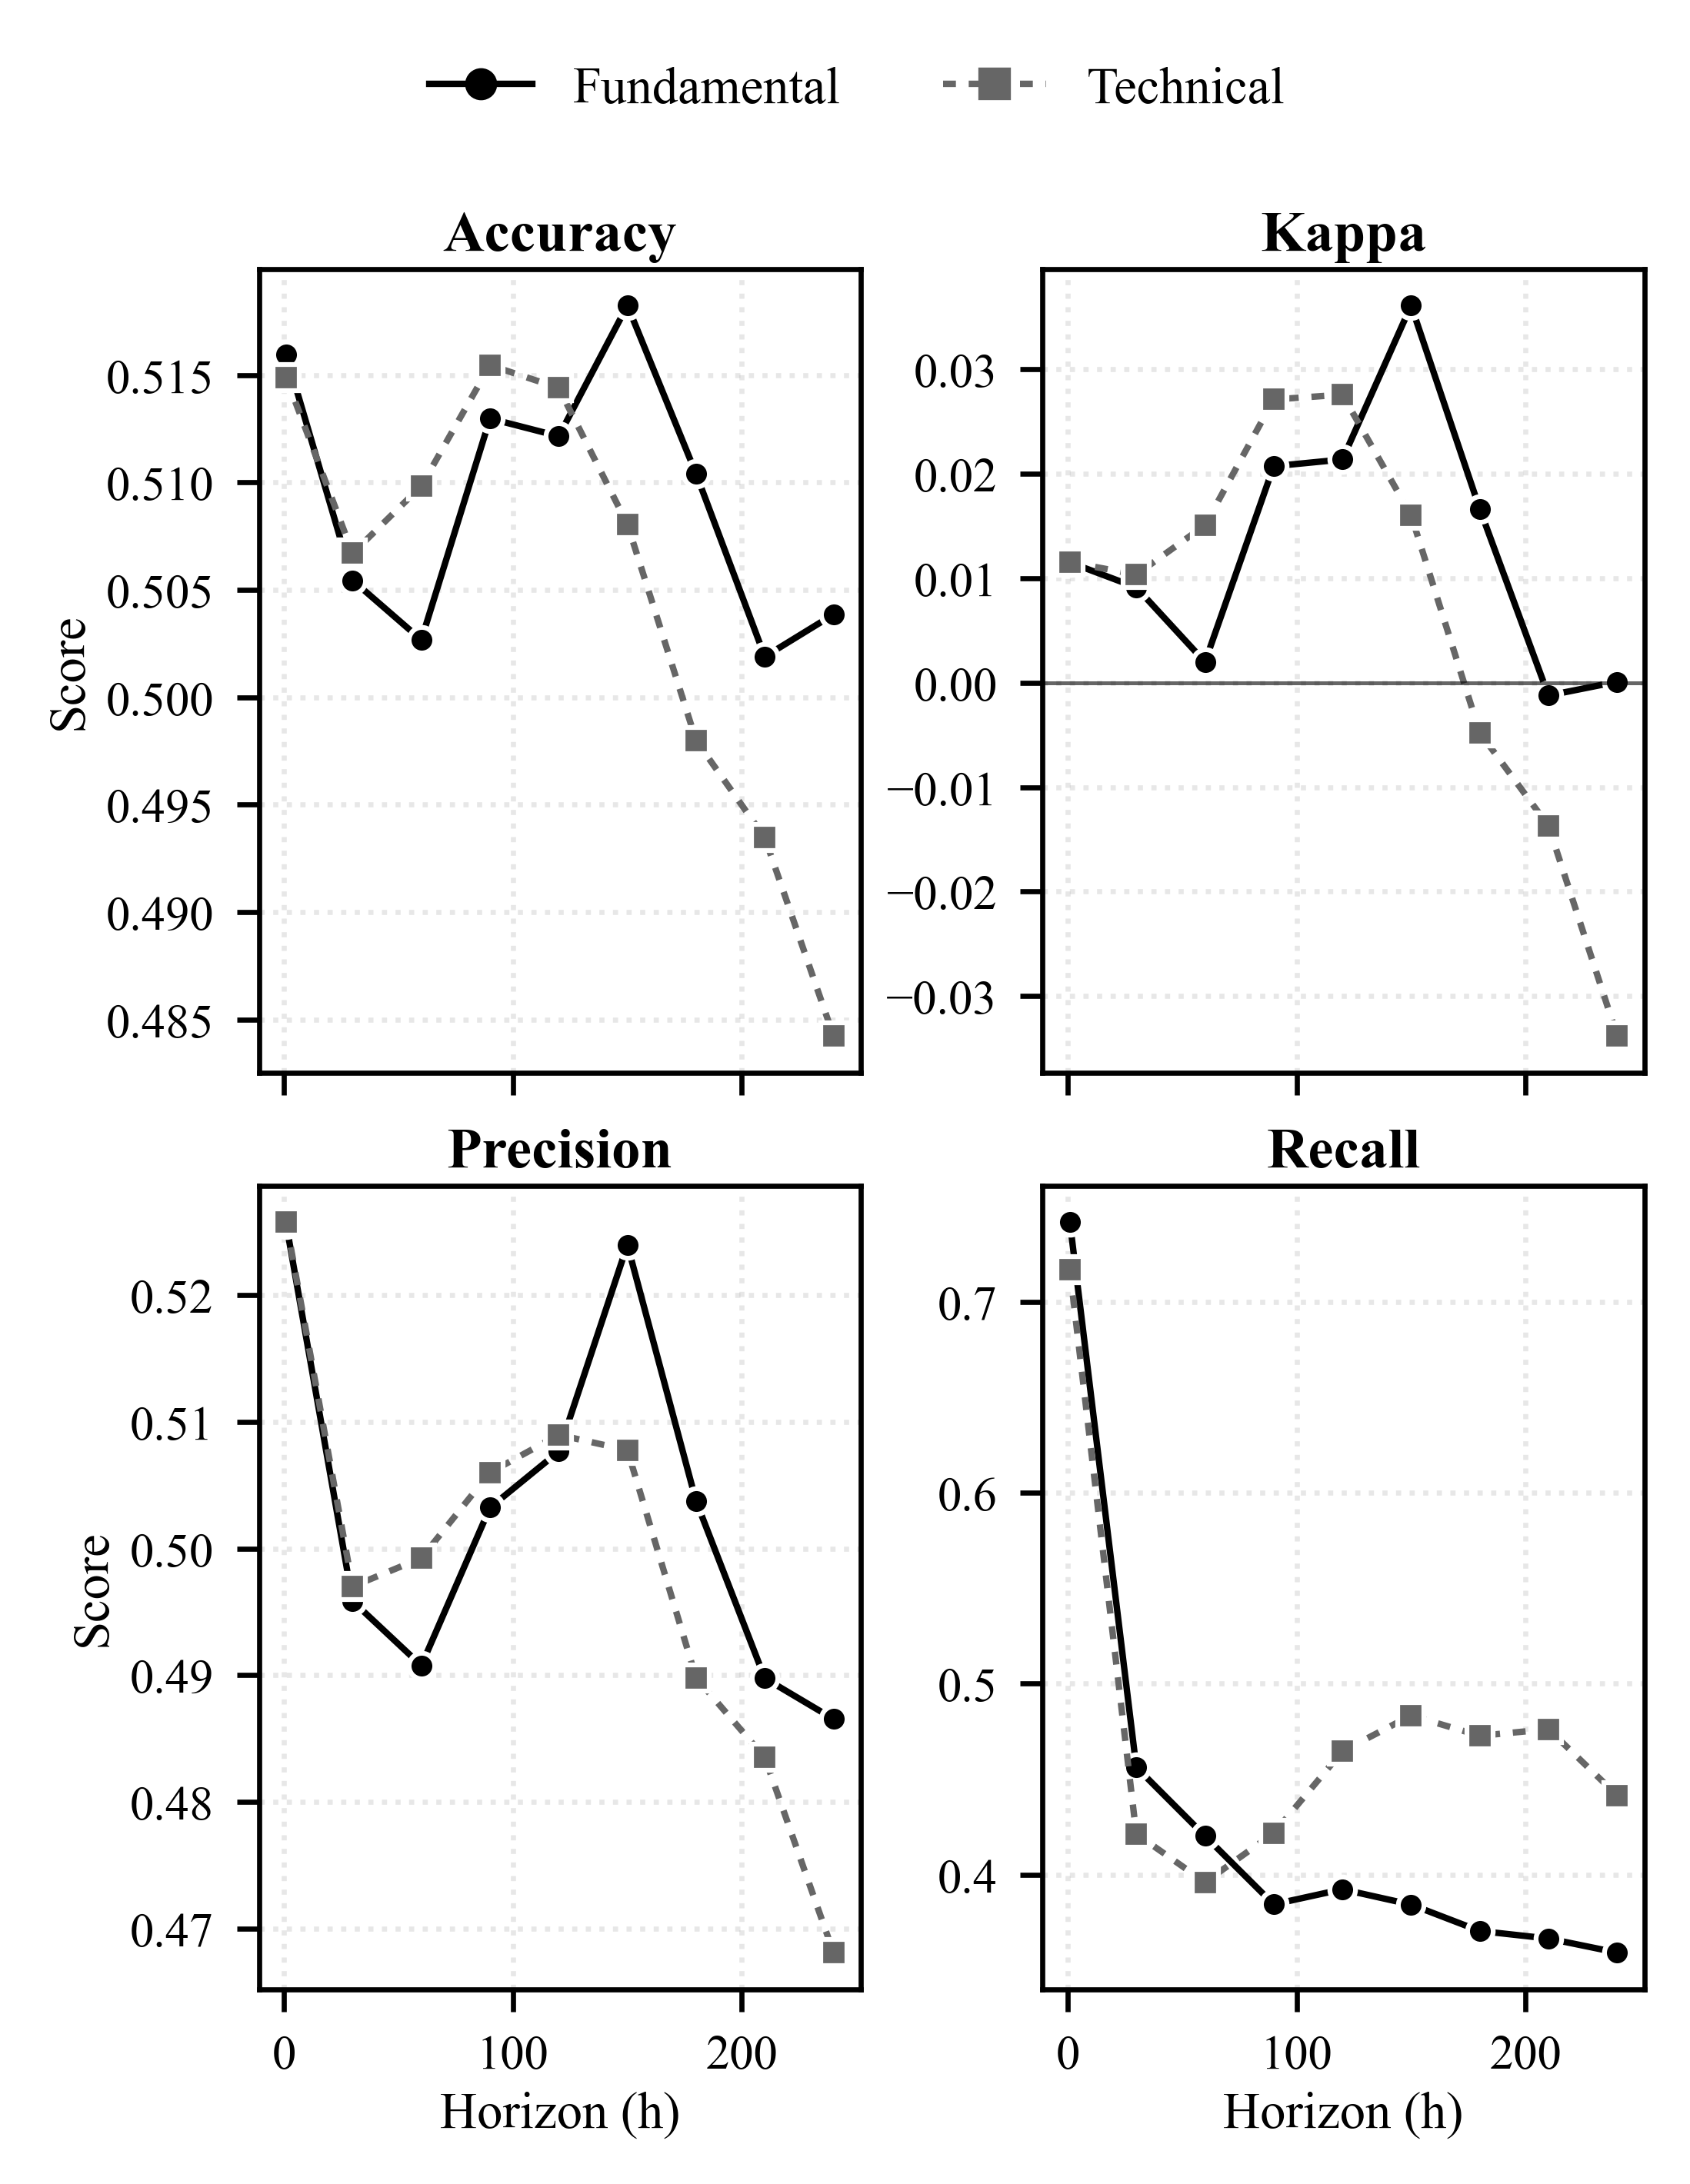

Salvo com fonte maior: figuras/global_metrics.pdf


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import matplotlib.font_manager as fm
import numpy as np

# ==============================================================================
# 1. CARREGAMENTO DA FONTE (TIMES NEW ROMAN)
# ==============================================================================
caminhos_possiveis = [
    os.path.expanduser('~/.local/share/fonts/times.ttf'),
    os.path.expanduser('~/.local/share/fonts/Times New Roman.ttf'),
    '/usr/share/fonts/truetype/msttcorefonts/Times_New_Roman.ttf',
    'C:/Windows/Fonts/times.ttf'
]

caminho_fonte = None
for p in caminhos_possiveis:
    if os.path.exists(p):
        caminho_fonte = p
        break

try:
    if caminho_fonte:
        fm.fontManager.addfont(caminho_fonte)
        prop = fm.FontProperties(fname=caminho_fonte)
        nome_exato_fonte = prop.get_name()
    else:
        nome_exato_fonte = 'serif'
except:
    nome_exato_fonte = 'serif'

# ==============================================================================
# 2. DADOS (Carregamento ou Simulação)
# ==============================================================================
atraso_selecionado = 10
caminho_arquivo = f'resultados/resultados_HT_atraso_{atraso_selecionado}.csv'
if not os.path.exists(caminho_arquivo):
    # Mock para garantir execução
    data = []
    horizons = [1, 30, 60, 90, 120, 150, 180, 210, 240]
    for h in horizons:
        data.append({'fh': h, 'Domain': 'Fundamental', 'Accuracy': 0.5+h/1000, 'Kappa': 0.02+h/2000, 'Precision': 0.51, 'Recall': 0.52})
        data.append({'fh': h, 'Domain': 'Technical', 'Accuracy': 0.5-h/1000, 'Kappa': -0.01-h/2000, 'Precision': 0.49, 'Recall': 0.48})
    df_global = pd.DataFrame(data)
else:
    df = pd.read_csv(caminho_arquivo)
    if 'fh' in df.columns: df.rename(columns={'fh': 'horizon'}, inplace=True)
    mapa = {'fund': 'Fundamental', 'nao_fund': 'Technical'}
    df['Domain'] = df['categoria'].map(mapa)
    df_grouped = df.groupby(['horizon', 'Domain'])[['TP', 'TN', 'FP', 'FN']].sum().reset_index()
    total = df_grouped['TP'] + df_grouped['TN'] + df_grouped['FP'] + df_grouped['FN']
    df_grouped['Accuracy'] = (df_grouped['TP'] + df_grouped['TN']) / total
    df_grouped['Precision'] = df_grouped['TP'] / (df_grouped['TP'] + df_grouped['FP'])
    df_grouped['Recall'] = df_grouped['TP'] / (df_grouped['TP'] + df_grouped['FN'])
    po = df_grouped['Accuracy']
    pe_pos = ((df_grouped['TP']+df_grouped['FP'])*(df_grouped['TP']+df_grouped['FN']))/(total**2)
    pe_neg = ((df_grouped['TN']+df_grouped['FN'])*(df_grouped['TN']+df_grouped['FP']))/(total**2)
    df_grouped['Kappa'] = (po - (pe_pos+pe_neg)) / (1 - (pe_pos+pe_neg))
    df_global = df_grouped.rename(columns={'horizon': 'fh'})

# ==============================================================================
# 3. CONFIGURAÇÃO IEEE (FONTE MAIOR)
# ==============================================================================
IEEE_COL_WIDTH = 3.5 
# Aumentei a altura para 4.5 para dar "respiro" às letras maiores
IEEE_HEIGHT = 4.5  

plt.rcParams.update({
    'font.family': nome_exato_fonte,
    'font.size': 8,              # <-- VOLTAMOS PARA 8pt (Padrão legível)
    'axes.labelsize': 8,         
    'axes.titlesize': 9,         # Títulos levemente maiores
    'legend.fontsize': 7.5,      # Legenda legível
    'xtick.labelsize': 7.5,
    'ytick.labelsize': 7.5,
    'figure.dpi': 600,
    'lines.linewidth': 1.0,      # Linha um pouco mais grossa para acompanhar a fonte
    'lines.markersize': 4,       
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': ':'
})

metrics_to_plot = {
    'Accuracy': 'Accuracy', 'Kappa': 'Kappa',
    'Precision': 'Precision', 'Recall': 'Recall'
}
palette = {'Fundamental': 'black', 'Technical': '#666666'}
markers = {'Fundamental': 'o', 'Technical': 's'}
dashes = {'Fundamental': (None, None), 'Technical': (2, 2)}

# ==============================================================================
# 4. PLOTAGEM
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(IEEE_COL_WIDTH, IEEE_HEIGHT), sharex=True)
axes = axes.flatten()

handles, labels = [], []

for i, (metric, title) in enumerate(metrics_to_plot.items()):
    ax = axes[i]
    if metric in df_global.columns:
        sns.lineplot(data=df_global, x='fh', y=metric, hue='Domain', style='Domain',
                     palette=palette, markers=markers, dashes=dashes, ax=ax, legend=True)
        if i == 0: handles, labels = ax.get_legend_handles_labels()
        if ax.get_legend(): ax.get_legend().remove()
    
    ax.set_title(title, fontweight='bold', pad=3)
    
    # Label Y apenas na esquerda
    if i % 2 == 0: 
        ax.set_ylabel('Score', labelpad=2) 
    else: 
        ax.set_ylabel('') 
        
    if 'Kappa' in metric:
        ax.axhline(0, color='black', linewidth=0.6, alpha=0.6)

# Label X embaixo
axes[2].set_xlabel('Horizon (h)', labelpad=2)
axes[3].set_xlabel('Horizon (h)', labelpad=2)

# Legenda no topo
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.03), 
           ncol=2, frameon=False, fontsize=8)

plt.tight_layout(pad=0.4, w_pad=0.5, h_pad=0.8) # Espaçamento um pouco maior
plt.subplots_adjust(top=0.91) # Espaço para a legenda

nome_saida = f'figuras/global_metrics_lag{atraso_selecionado}.pdf'
# plt.savefig(nome_saida, format='pdf', dpi=600, bbox_inches='tight')
plt.show()
print(f"Salvo com fonte maior: {nome_saida}")